In [1]:
# Imports
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import time
import random

In [2]:
# Reading in data 
data = pd.read_csv("../datasets/mnist/train.csv")

In [3]:
# Data preview
data.head() # just a test to see the data

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Convert to np array for vectorization
data = np.array(data)
m, n = data.shape
print(f"{m} training examples with {np.sqrt(n - 1)} by {np.sqrt(n - 1)} pixels.")

42000 training examples with 28.0 by 28.0 pixels.


In [5]:
# Splitting into a validation and training data set (another testing set is provided)

np.random.shuffle(data)
X = data[:, 1:] / 255 # everything but first column of data
y = data[:, 0] # the first column of data
split = round(X.shape[0] * 0.7) # accounting for roundoff errors

# Training set 
x_train = X[:split].T
y_train = np.zeros((10, split))
col = 0
for label in y[:split]:
    y_train[label, col] = 1
    col += 1

# Validation set
x_dev = X[split:].T
y_dev = np.zeros((10, m - split))
col = 0
for label in y[split:]:
    y_dev[label, col] = 1
    col += 1

In [6]:
# Softmax (w/ batch handling)
def softmax(Z):
    """
    Z: shape (units_in_layer, m)
    returns: shape (units_in_layer, m)
    """
    Z = Z - np.max(Z, axis=0, keepdims=True)
    Z = np.exp(Z)
    A = Z / np.sum(Z, axis=0, keepdims=True)
    return A

In [7]:
# Layer (w/ batch handling)
class DenseLayer:
    def __init__(self, units, input_size, activation):
        self.W = np.random.randn(units, input_size) * np.sqrt(2 / input_size)
        self.b = np.zeros((units, 1))  # column vector
        self.activation = activation
        functions = {
            "relu": lambda Z: np.maximum(0, Z),
            "sigmoid": lambda Z: 1 / (1 + np.exp(-Z)),
            "linear": lambda Z: Z,
            "softmax": softmax
        }
        self.g = functions[activation]

    def forward(self, A_in):
        """
        A_in: shape (input_size, m), each column is a training example
        Returns: shape (units, m), each column is a prediction vector
        """
        self.A_in = A_in
        self.Z = np.matmul(self.W, A_in) + self.b
        self.A_out = self.g(self.Z)
        return self.A_out

    def dA_dZ(self):
        if self.activation == "relu":
            return (self.Z > 0).astype(float)
            
        elif self.activation == "sigmoid":
            S = self.A_out # A_out is the sigmoid
            return S * (1 - S)
        
        elif self.activation == "linear":
            return np.ones_like(self.Z)
        
        elif self.activation == "softmax":
            # When used with cross-entropy, dZ = A_hat - Y is handled in backprop directly.
            # This derivative should NOT be used for the output layer in that case. (courtesy gpt)
            return np.ones_like(self.Z)
        else:
            raise ValueError(f"Unsupported activation: {self.activation}")



In [8]:
# Neural Network (w/ batch handling)
class NeuralNet:
    def __init__(self, *layers):
        self.layers = layers
        for i in range(1, len(layers)):
            layers[i].prev = layers[i - 1]  

    def forward_prop(self, A):
        """
        A: shape (784, m) where each column is an example
        """
        for layer in self.layers:
            A = layer.forward(A)
        return A

    def back_prop(self, A_hat, Y, alpha=0.01):
        _, m_batch = A_hat.shape
        error = A_hat - Y  # dZ of output layer
    
        for i in reversed(range(len(self.layers))):
            layer = self.layers[i]
    
            # Compute gradients for current layer
            dW = (1 / m_batch) * np.dot(error, layer.A_in.T)
            db = (1 / m_batch) * np.sum(error, axis=1, keepdims=True)
            
            # Gradient clipping to prevent overflow
            dW = np.clip(dW, -1.0, 1.0)
            db = np.clip(db, -1.0, 1.0)
    
            # Update weights and biases
            layer.W -= alpha * dW
            layer.b -= alpha * db
    
            # Compute dZ for previous layer (excluding input layer)
            if i > 0:
                prev_layer = self.layers[i - 1]
                dA_prev = np.dot(layer.W.T, error)
                error = dA_prev * prev_layer.dA_dZ()  # derivative of prev layer's activation
                # Clip error to prevent explosion in next layer
                error = np.clip(error, -1e3, 1e3)

    def cost(self, A_hat, Y):
        """
        A_hat: shape (10, m), each column is a prediction vector
        Y: shape (10, m), each column is a one-hot encoded vector
        """
        _, m_batch = A_hat.shape
        log_preds = np.log(A_hat + 1e-8)  # avoiding log(0)
        loss = Y * log_preds
        cost = - (np.sum(loss) / m_batch)
        return cost

    def train(self, X, Y, alpha=0.01, batch_size=64, epochs=50):
        start = time.time() # Timing model

        for _ in range(epochs):
            # Splitting into batches and training
            for i in range(0, X.shape[1], batch_size):
                x_batch = X[:, i:i+batch_size]
                y_batch = Y[:, i:i+batch_size]
        
                y_hat = self.forward_prop(x_batch)
                self.back_prop(y_hat, y_batch, alpha)

        end = time.time() # Training complete

        print(f"Completed in {end - start} seconds.") # Completion message

    def accuracy(self, X, Y):
        y_hat = softmax(self.forward_prop(X))
        y_hat = y_hat / np.max(y_hat, axis=0, keepdims=True)
        mask = (y_hat != 1)
        y_hat[mask] = 0
        correct = np.sum(y_hat * Y)
        return correct / X.shape[1]
        

In [9]:
# Creating model
model = NeuralNet(
    DenseLayer(units=25, input_size=784, activation='relu'),
    DenseLayer(units=15, input_size=25, activation='relu'),
    DenseLayer(units=10, input_size=15, activation='softmax')
)

# Training the model
model.train(x_train, y_train, alpha=1e-3, batch_size=64, epochs=300)

KeyboardInterrupt: 

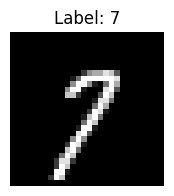

Guess: 7
Predictions:
0: 0.02%
1: 0.15%
2: 0.15%
3: 0.05%
4: 0.01%
5: 0.09%
6: 0.00%
7: 97.33%
8: 0.06%
9: 2.14%


In [ ]:
# Testing (single data point)
index = random.randint(0, x_train.shape[1])
test = x_train[:, index].reshape(-1, 1)
result = y_train[:, index].reshape(-1, 1)

# Drawing the input digit (courtesy of gpt)
plt.figure(figsize=(2, 2))
plt.imshow(test.reshape(28, 28), cmap='gray', interpolation='nearest')
plt.title(f"Label: {np.argmax(result)}")
plt.axis('off')
plt.show()

# Predicting
probabilities = model.forward_prop(test) 
percentages = probabilities * 100 
guess = np.argmax(probabilities)

print(f"Guess: {guess}")
print("Predictions:")
for digit, pct in enumerate(percentages.flatten()):
    print(f"{digit}: {pct:.2f}%")

In [ ]:
# Accuracy Test
training_accuracy = model.accuracy(x_train, y_train) * 100
validation_accuracy = model.accuracy(x_dev, y_dev) * 100
print(f"Training accuracy = {training_accuracy:.2f}%")
print(f"Validation accuracy = {validation_accuracy:.2f}%")

Training accuracy = 95.33%
Validation accuracy = 93.99%
